# ***BUSH FIRE DETECTION (AUSTRALIA)***

THE PROVENANCE FOR THE DATA THAT WE HAVE CHOSEN TO HELP IN DETECTION OF BUSH FIRE IS AS FOLLOWS:
DATA: https://www.kaggle.com/datasets/nagarajbhat/australian-bush-fire-satellite-data-nasa?select=Readme_nasa.txt

About Data: Files are classified as Archive or NRT.
The archive data is older and well calibrated. Whereas NRT(near real time) data is generated within just 3 hours of satellite detection. It is to support the immediate needs.
Archive data is between sept 1,2019 to Dec 31, 2019.
Whereas NRT data is between Jan 1,2020 to Jan 31,2020.
Both the files can be merged.


In [2]:
#MAIN IMPORTS
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
!pip install geopandas
import geopandas as gpd



[notice] A new release of pip is available: 23.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip


In [10]:
#IMPORTING DATASET

df_M6_1 = pd.read_csv("fire_archive_M6_101673.csv") 
df_V1_1 = pd.read_csv("fire_archive_V1_101674.csv")
df_M6_2 = pd.read_csv("fire_nrt_M6_101673.csv")
df_V1_2 = pd.read_csv("fire_nrt_V1_101674.csv")
df_V1 = pd.concat([df_V1_1, df_V1_2])
df_M6 = pd.concat([df_M6_1, df_M6_2])

# df_V1.dropna(subset = ['bright_ti4','scan','track','acq_time', 'bright_ti5','frp'])
# df_M6.dropna(subset = ['brightness','scan','track','acq_time', 'bright_t31','frp'])

df_V1.info()
df_M6.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1119683 entries, 0 to 1013969
Data columns (total 15 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   latitude    1119683 non-null  float64
 1   longitude   1119683 non-null  float64
 2   bright_ti4  1119683 non-null  float64
 3   scan        1119683 non-null  float64
 4   track       1119683 non-null  float64
 5   acq_date    1119683 non-null  object 
 6   acq_time    1119683 non-null  int64  
 7   satellite   1119683 non-null  object 
 8   instrument  1119683 non-null  object 
 9   confidence  1119683 non-null  object 
 10  version     1119683 non-null  object 
 11  bright_ti5  1119683 non-null  float64
 12  frp         1119683 non-null  float64
 13  type        105713 non-null   float64
 14  daynight    1013970 non-null  object 
dtypes: float64(8), int64(1), object(6)
memory usage: 136.7+ MB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 183163 entries, 0 to 34855
Data columns (t

In [11]:
#CONFIDENCE COLUMN -> CONVERT TO NUMERICAL VALUES 
df_V1['confidence_encoded'] = df_V1['confidence'].map({'l': 0, 'n': 1, 'h' : 2})
df_V1["confidence_encoded"] = df_V1["confidence_encoded"].astype("int64")
df_V1.dropna()
df_V1

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,type,daynight,confidence_encoded
0,-37.48861,149.63156,341.1,0.41,0.60,2019-09-01,304,N,VIIRS,n,1,293.7,4.4,0.0,NaN,1
1,-34.46110,150.88142,328.5,0.33,0.55,2019-09-01,305,N,VIIRS,l,1,298.5,2.1,2.0,NaN,0
2,-33.94823,151.21292,341.1,0.62,0.54,2019-09-01,305,N,VIIRS,n,1,295.3,6.4,0.0,NaN,1
3,-34.45618,150.87723,328.5,0.33,0.55,2019-09-01,305,N,VIIRS,n,1,298.1,2.1,2.0,NaN,1
4,-31.60223,150.15147,367.0,0.34,0.56,2019-09-01,306,N,VIIRS,h,1,302.4,19.3,0.0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013965,-32.40507,122.99978,302.6,0.39,0.44,2020-01-30,1712,N,VIIRS,n,1.0NRT,287.2,1.0,NaN,N,1
1013966,-32.41772,123.00198,309.1,0.39,0.44,2020-01-30,1712,N,VIIRS,n,1.0NRT,286.8,1.5,NaN,N,1
1013967,-32.41727,122.99780,298.1,0.39,0.44,2020-01-30,1712,N,VIIRS,n,1.0NRT,285.9,0.9,NaN,N,1
1013968,-32.41411,123.00684,306.1,0.39,0.44,2020-01-30,1712,N,VIIRS,n,1.0NRT,286.6,1.1,NaN,N,1


In [12]:
quart_1 = np.quantile(df_M6['confidence'], 0.25)
print('1st quartile:', quart_1)
quart_2 = np.quantile(df_M6['confidence'], 0.5)
print('2nd quartile:', quart_2)
quart_3 = np.quantile(df_M6['confidence'], 0.75)
print('3rd quartile:', quart_3)
quart_4 = np.quantile(df_M6['confidence'], 1.0)
print('4th quartile:', quart_4)

#for less than 2 quantiles : confidence = 0; for between 2nd and 3rd quantile : confidence = 1; for between 3rd and 4th quantile : confidence = 2
df_M6["confidence_encoded"] = pd.cut(df_M6["confidence"], bins=[-1, 58, 81, 98, 100], labels=[0, 0, 1, 2], ordered=False)
print(len(df_M6['confidence']), len(df_M6["confidence_encoded"]))
df_M6["confidence_encoded"] = df_M6["confidence_encoded"].astype("float64")
df_M6.dropna()
df_M6

1st quartile: 58.0
2nd quartile: 81.0
3rd quartile: 98.0
4th quartile: 100.0
183163 183163


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,confidence_encoded
0,-12.3168,142.0542,311.4,4.2,1.9,2019-09-01,14,Terra,MODIS,23,6.3,297.0,40.2,D,0.0,0.0
1,-12.3407,142.0894,310.2,4.2,1.9,2019-09-01,14,Terra,MODIS,18,6.3,296.9,33.5,D,0.0,0.0
2,-12.3266,142.0863,310.1,4.2,1.9,2019-09-01,14,Terra,MODIS,27,6.3,296.7,36.0,D,0.0,0.0
3,-12.6649,142.6015,310.4,3.8,1.8,2019-09-01,14,Terra,MODIS,35,6.3,298.1,28.2,D,0.0,0.0
4,-12.8706,142.7663,314.3,3.6,1.8,2019-09-01,14,Terra,MODIS,56,6.3,299.4,43.5,D,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34851,-36.3520,149.5570,307.2,2.2,1.4,2020-01-30,1540,Aqua,MODIS,57,6.0NRT,291.6,24.1,N,NaN,0.0
34852,-36.3630,149.5310,317.3,2.2,1.4,2020-01-30,1540,Aqua,MODIS,92,6.0NRT,290.3,47.0,N,NaN,1.0
34853,-41.5760,147.7890,306.2,2.0,1.4,2020-01-30,1545,Aqua,MODIS,65,6.0NRT,290.6,20.7,N,NaN,0.0
34854,-41.5890,147.7860,304.0,2.0,1.4,2020-01-30,1545,Aqua,MODIS,39,6.0NRT,290.7,16.9,N,NaN,0.0


In [13]:
corr_V1 = df_V1.corr()
corr_V1.style.background_gradient(cmap='PuOr_r')

/var/folders/nb/n136r3ns1zb7y11vgm369rfc0000gn/T/ipykernel_67683/3243013604.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_V1 = df_V1.corr()


,latitude,longitude,bright_ti4,scan,track,acq_time,bright_ti5,frp,type,confidence_encoded
latitude,1.000000,-0.404740,0.142739,0.015063,0.058664,-0.227170,0.243828,-0.064744,-0.036457,-0.073179
longitude,-0.404740,1.000000,-0.199063,-0.040432,-0.126458,0.104951,-0.299144,-0.054198,-0.026737,0.008510
bright_ti4,0.142739,-0.199063,1.000000,-0.040779,-0.021412,-0.725574,0.677341,0.290829,-0.037586,0.255378
scan,0.015063,-0.040432,-0.040779,1.000000,0.530126,-0.017889,-0.074358,0.023675,-0.002685,0.007026
track,0.058664,-0.126458,-0.021412,0.530126,1.000000,-0.074794,-0.123391,-0.013216,-0.009307,0.141257
acq_time,-0.227170,0.104951,-0.725574,-0.017889,-0.074794,1.000000,-0.632984,-0.222908,0.032020,-0.020269
bright_ti5,0.243828,-0.299144,0.677341,-0.074358,-0.123391,-0.632984,1.000000,0.435116,-0.038739,0.042396
frp,-0.064744,-0.054198,0.290829,0.023675,-0.013216,-0.222908,0.435116,1.000000,-0.012472,0.122775
type,-0.036457,-0.026737,-0.037586,-0.002685,-0.009307,0.032020,-0.038739,-0.012472,1.000000,-0.002057
confidence_encoded,-0.073179,0.008510,0.255378,0.007026,0.141257,-0.020269,0.042396,0.122775,-0.002057,1.000000


In [14]:
corr_M6 = df_M6.corr()
corr_M6.style.background_gradient(cmap='PuOr_r')

/var/folders/nb/n136r3ns1zb7y11vgm369rfc0000gn/T/ipykernel_67683/2672783990.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_M6 = df_M6.corr()


,latitude,longitude,brightness,scan,track,acq_time,confidence,bright_t31,frp,type,confidence_encoded
latitude,1.000000,-0.410281,-0.096068,0.076601,0.081531,-0.235878,-0.066562,0.168618,-0.097161,-0.017629,-0.168513
longitude,-0.410281,1.000000,-0.107625,-0.121951,-0.127085,0.181447,-0.052374,-0.305903,-0.064572,-0.033967,0.000972
brightness,-0.096068,-0.107625,1.000000,-0.106967,-0.114748,-0.302752,0.531152,0.684595,0.631259,-0.029414,0.604006
scan,0.076601,-0.121951,-0.106967,1.000000,0.982930,-0.018234,-0.102375,-0.099329,0.183865,-0.012571,-0.121336
track,0.081531,-0.127085,-0.114748,0.982930,1.000000,-0.010770,-0.107795,-0.102119,0.178375,-0.014591,-0.127590
acq_time,-0.235878,0.181447,-0.302752,-0.018234,-0.010770,1.000000,-0.058251,-0.448394,-0.082515,-0.013056,0.052968
confidence,-0.066562,-0.052374,0.531152,-0.102375,-0.107795,-0.058251,1.000000,0.270612,0.246908,-0.035219,0.788719
bright_t31,0.168618,-0.305903,0.684595,-0.099329,-0.102119,-0.448394,0.270612,1.000000,0.375173,-0.009806,0.221567
frp,-0.097161,-0.064572,0.631259,0.183865,0.178375,-0.082515,0.246908,0.375173,1.000000,-0.014088,0.322738
type,-0.017629,-0.033967,-0.029414,-0.012571,-0.014591,-0.013056,-0.035219,-0.009806,-0.014088,1.000000,-0.028311


# ***PLOTTING THE LOCATIONS OF BRIGHT PIXEL SPOTS DETECTED BY THE SATELLITE ON THE MAP OF AUSTRALIA***

In [15]:
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

countries


/var/folders/nb/n136r3ns1zb7y11vgm369rfc0000gn/T/ipykernel_67683/3477789667.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."
...,...,...,...,...,...,...
172,6944975.0,Europe,Serbia,SRB,51475,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,622137.0,Europe,Montenegro,MNE,5542,"POLYGON ((20.07070 42.58863, 19.80161 42.50009..."
174,1794248.0,Europe,Kosovo,-99,7926,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,1394973.0,North America,Trinidad and Tobago,TTO,24269,"POLYGON ((-61.68000 10.76000, -61.10500 10.890..."


<Axes: >

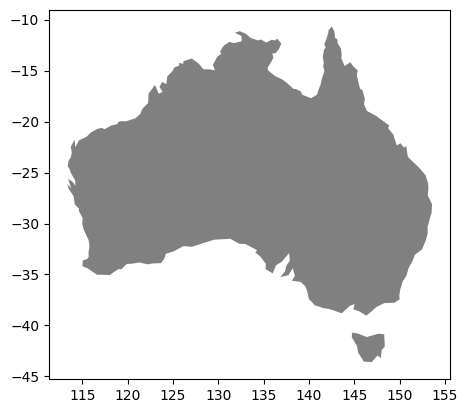

In [18]:
countries[countries["name"] == "Australia"].plot(color="grey")

## *LOCATIONS OF BRIGHT PIXEL SPOTS DETECTED BY THE SATELLITE -* ***MODIS***

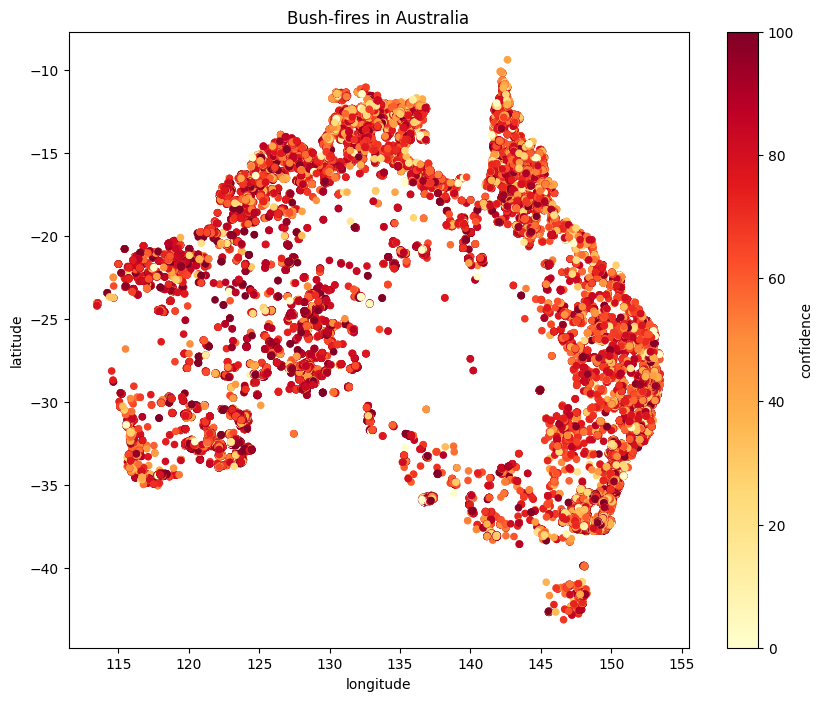

In [16]:
# initialize an axis
fig, ax = plt.subplots(figsize=(10,8))

# plot points
df_M6.plot(x="longitude", y="latitude", kind="scatter", c="confidence", colormap="YlOrRd", 
        title="Bush-fires in Australia", ax=ax)

plt.show()

## *LOCATIONS OF BRIGHT PIXEL SPOTS DETECTED BY THE SATELLITE -* ***VIIRS***

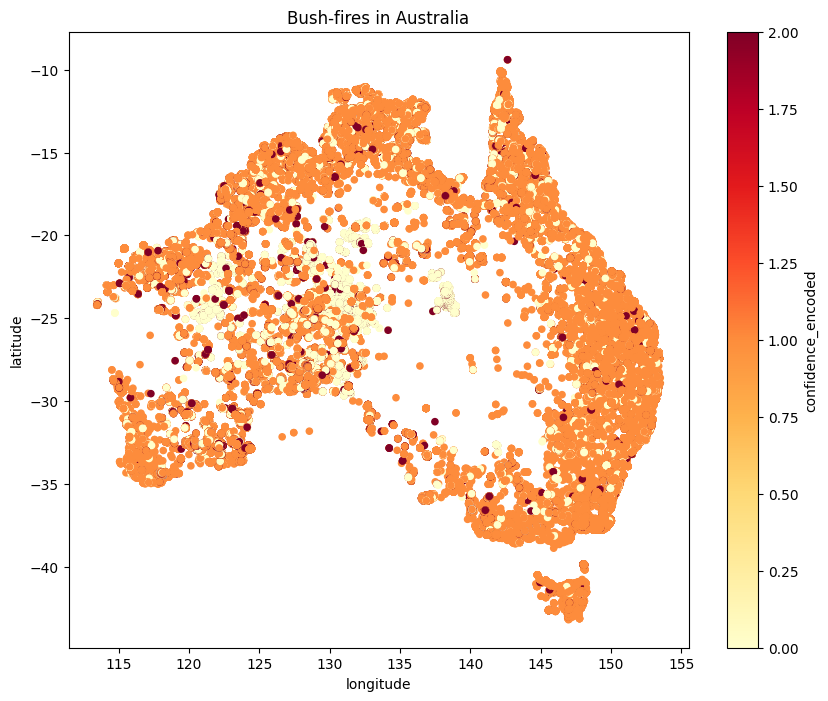

In [17]:
fig, ax = plt.subplots(figsize=(10,8))

# plot points
df_V1.plot(x="longitude", y="latitude", kind="scatter", c="confidence_encoded", colormap="YlOrRd", 
        title="Bush-fires in Australia", ax=ax)

plt.show()

# **SUPERVISED LEARNING**

## ***LINEAR REGRESSION***

In [19]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


x = df_M6[['brightness', 'bright_t31', 'scan', 'track', 'frp']]
X_linear_M6 = np.array(x)
y_linear_M6 = df_M6["confidence_encoded"]

# Train/test splits, remember the random state issue
X_train, X_test, y_train, y_test = train_test_split(X_linear_M6, y_linear_M6, test_size=0.2, random_state=100)

# Build the Linear Regression model
reg = LinearRegression().fit(X_train, y_train)
# Predict the target
y_pred = reg.predict(X_test)


# Obtain the coefficient of determination of the prediction
R2 = r2_score(y_test, y_pred)

# Pandas DataFrame with the actual and predicted values
results_M6 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results_M6)
                          
                          
# Obtain the mean square error of the prediction
mse = mean_squared_error(y_test, y_pred)
# acc = accuracy_score(y_test, y_pred)
# print("Accuracy", acc)
print("The R2 of the testing set by LR is {:.2f}".format(R2))
print("The mean square error of the testing set by LR is {:.2f}".format(mse))


print('------------------------------------------------------------------------')
x = df_V1[['bright_ti4', 'bright_ti5', 'frp', 'scan', 'track']]
X_linear_V1 = np.array(x)
y_linear_V1 = df_V1['confidence_encoded']


# Train/test splits, remember the random state issue
X_train, X_test, y_train, y_test = train_test_split(X_linear_V1, y_linear_V1, test_size=0.2, random_state=100)

# Build the Linear Regression model
reg = LinearRegression().fit(X_train,y_train)
# Predict the target
y_pred = reg.predict(X_test)

# Pandas DataFrame with the actual and predicted values
results_V1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results_V1)

# Obtain the coefficient of determination of the prediction
R2 = r2_score(y_test, y_pred)
# if R2_score is 1 then it means that the model explains 100% of the fitted data in the regression model
# Obtain the mean square error of the prediction
mse = mean_squared_error(y_test, y_pred)
#if mse = 0 it means the model is perfect

print("The R2 of the testing set by LR is {:.2f}".format(R2))
print("The mean square error of the testing set by LR is {:.2f}".format(mse))

        Actual  Predicted
31698      1.0   0.812339
25428      1.0   0.878807
32406      0.0   0.569742
32999      0.0   0.147618
83643      1.0   0.479970
...        ...        ...
55766      1.0   0.531511
74104      0.0   0.280405
126796     0.0   0.284886
33269      0.0   0.743938
25005      0.0   0.133255

[36633 rows x 2 columns]
The R2 of the testing set by LR is 0.45
The mean square error of the testing set by LR is 0.38
------------------------------------------------------------------------
        Actual  Predicted
77077        1   1.150008
565509       1   1.046488
578227       0   1.058880
881113       1   0.876505
111737       1   0.855242
...        ...        ...
567272       0   0.905074
981857       1   0.882494
643093       1   1.013680
615281       1   1.051641
106927       1   0.871871

[223937 rows x 2 columns]
The R2 of the testing set by LR is 0.13
The mean square error of the testing set by LR is 0.16


## ***K-NEIGHBORING NEIGHBORS***

***CLASSIFICATION***

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load the dataset
X = df_M6[['latitude', 'longitude', 'brightness', 'acq_time', 'bright_t31', 'frp', 'scan', 'track']]
y = df_M6['confidence_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Create a KNN model object
knn = KNeighborsClassifier(n_neighbors=15)

# Train the model on the training set
knn.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = knn.predict(X_test)

# Calculate the accuracy score & F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = "weighted")
# Print the accuracy score
print("Accuracy score for M6: {:.2f}%".format(accuracy * 100))
print("F1 score for M6: {:.2f}%".format(f1 * 100))
print('----------------------------------------------------------------------------')

X = df_V1[['bright_ti4', 'bright_ti5', 'acq_time', 'frp', 'latitude', 'longitude', 'scan', 'track']]
y = df_V1['confidence']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Create a KNN model object
knn = KNeighborsClassifier(n_neighbors=15)

# Train the model on the training set
knn.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = knn.predict(X_test)

# Calculate the accuracy score & F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = "weighted")
# Print the accuracy score
print("Accuracy score for V1: {:.2f}%".format(accuracy * 100))
print("F1 score for V1: {:.2f}%".format(f1 * 100))

Accuracy score for M6: 85.26%
F1 score for M6: 85.09%
----------------------------------------------------------------------------
Accuracy score for V1: 95.78%
F1 score for V1: 95.63%


***REGRESSION***

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import precision_score

x = df_M6[['latitude', 'longitude', 'brightness', 'acq_time', 'bright_t31', 'frp', 'scan', 'track']]
X_knn_M6 = np.array(x)
y_knn_M6 = df_M6[['confidence_encoded']]

X_train, X_test, y_train, y_test = train_test_split(X_knn_M6, y_knn_M6, test_size=0.2, random_state=100)

knn = KNeighborsRegressor(n_neighbors=15, weights = 'distance')
knn.fit(X_train, y_train)
# graph = knn.kneighbors_graph(X_train, n_neighbors=7)
# graph = graph.toarray()
y_pred = knn.predict(X_train)
pred = knn.predict(X_test)
 
mse = mean_squared_error(y_train, y_pred)
R2 = r2_score(y_test, pred)
print('MSE:', mse)
print('R2/Accuracy:', R2)

MSE: 0.0
R2/Accuracy: 0.7968388322361333


In [24]:
x = df_V1[['latitude', 'longitude', 'bright_ti4', 'bright_ti5', 'acq_time', 'frp', 'scan', 'track']]
X_knn_V1 = np.array(x)
y_knn_V1 = df_V1[['confidence_encoded']]


X_train, X_test, y_train, y_test = train_test_split(X_knn_V1, y_knn_V1, test_size=0.2, random_state=100)

knn = KNeighborsRegressor(n_neighbors=15, weights = 'distance')
knn.fit(X_train, y_train)
# graph = knn.kneighbors_graph(X_train, n_neighbors=7)
# graph = graph.toarray()

y_pred = knn.predict(X_train)
pred = knn.predict(X_test)
     
# A score = 1, means KNN tends to closely follow the training data and thus has high training score
V_mse = mean_squared_error(y_train, y_pred)
V_R2 = r2_score(y_test, pred)
print('MSE:', V_mse)
print('R2/Accuracy:', V_R2)

MSE: 0.0
R2/Accuracy: 0.7140226769042604


#***MULTI-LAYER PERCEPTRON (MLP)*** 

## M6 DATASET

Accuracy for the M6 dataset: 87.72%
roc_auc: 0.9686134236431414


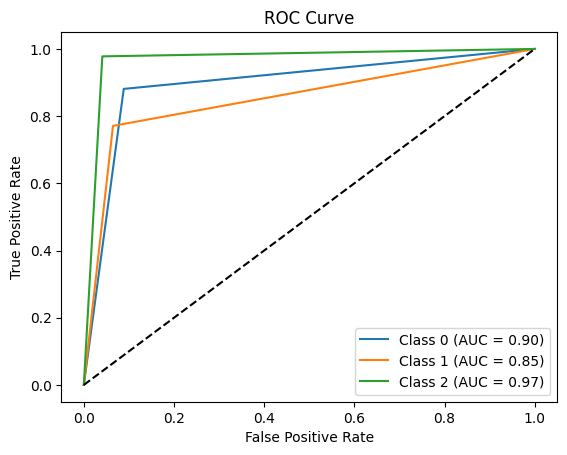

In [26]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df_M6 = df_M6.dropna()
x_mlp_1 = df_M6[['brightness','scan','track','acq_time', 'bright_t31','frp']]
x_mlp_M6 = np.array(x_mlp_1)

y_mlp_M6 = df_M6['confidence_encoded'].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(x_mlp_M6, y_mlp_M6, test_size=0.2, random_state=1000)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize an MLP classifier with two hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(100,50,30,20), max_iter=1000, random_state=42)

# Fit the model to the training data
mlp.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = mlp.predict(X_test_scaled)

y_scores = mlp.predict_proba(X_test_scaled)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores, multi_class='ovr')

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_pred_encoded = label_encoder.transform(y_pred)

# Print the accuracy score of the model
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print("Accuracy for the M6 dataset: {:.2f}%".format(accuracy * 100))
# print('fpr:', fpr)
# print('tpr:', tpr)
print('roc_auc:', roc_auc)

# Receiver Operating Characteristic (ROC) curve
n_classes = len(label_encoder.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    y_test_binary = np.where(y_test_encoded == i, 1, 0)
    y_pred_binary = np.where(y_pred_encoded == i, 1, 0)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc[i] = roc_auc_score(y_test_binary, y_pred_binary)

# Plot ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## V1 DATASET

Accuracy for the V1 dataset: 96.32%
roc_auc: 0.9933245703636079


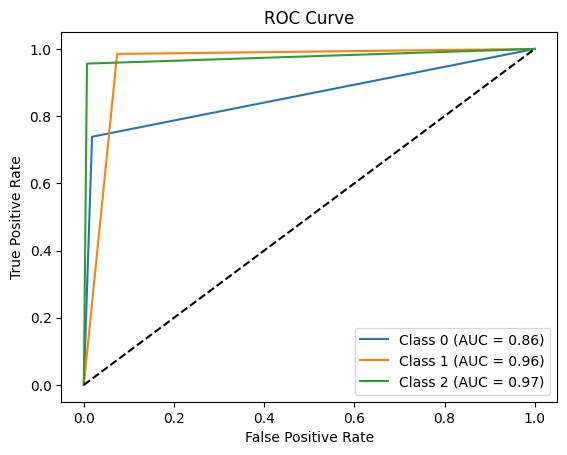

In [30]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

x_mlp_2 = df_V1[['bright_ti4','scan','track','acq_time', 'bright_ti5','frp']]
x_mlp_V1 = np.array(x_mlp_2)

y_mlp_V1 = df_V1[['confidence_encoded']].astype("float64").values.ravel()

X_train, X_test, y_train, y_test = train_test_split(x_mlp_V1, y_mlp_V1, test_size=0.2, random_state=1000)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize an MLP classifier with two hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(100,50,30,10), max_iter=1000, random_state=42)

# Fit the model to the training data
mlp.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = mlp.predict(X_test_scaled)

y_scores = mlp.predict_proba(X_test_scaled)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores, multi_class='ovr')

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_pred_encoded = label_encoder.transform(y_pred)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print("Accuracy for the V1 dataset: {:.2f}%".format(accuracy * 100))
print("roc_auc:", roc_auc)

# Receiver Operating Characteristic (ROC) curve
n_classes = len(label_encoder.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    y_test_binary = np.where(y_test_encoded == i, 1, 0)
    y_pred_binary = np.where(y_pred_encoded == i, 1, 0)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc[i] = roc_auc_score(y_test_binary, y_pred_binary)

# Plot ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


# ***NEURAL NETWORKS***

In [28]:
# import necessary libraries
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# select relevant columns and convert data types if necessary
df = df_M6[['brightness', 'scan', 'track', 'bright_t31', 'frp', 'confidence_encoded']]
df['confidence_encoded'] = df_M6['confidence_encoded'].astype(float)

# split data into training and testing sets
X = df.drop(['confidence_encoded'], axis=1)
y = df['confidence_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create a neural network with Keras
model = keras.Sequential([
    keras.layers.Dense(16, input_shape=(5,), activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2)

# evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)

# print the model's accuracy
print('Test accuracy for M6:', test_acc)
print('Test loss for M6:', test_loss)

Epoch 1/50


/var/folders/nb/n136r3ns1zb7y11vgm369rfc0000gn/T/ipykernel_67683/758183961.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['confidence_encoded'] = df_M6['confidence_encoded'].astype(float)


1484/1484 [==============================] - 1s 554us/step - loss: -89.9744 - accuracy: 0.5521 - val_loss: -357.5255 - val_accuracy: 0.5685
Epoch 2/50
1484/1484 [==============================] - 1s 453us/step - loss: -1179.9816 - accuracy: 0.5711 - val_loss: -2327.9697 - val_accuracy: 0.5672
Epoch 3/50
1484/1484 [==============================] - 1s 449us/step - loss: -4197.1587 - accuracy: 0.5697 - val_loss: -6454.6196 - val_accuracy: 0.5623
Epoch 4/50
1484/1484 [==============================] - 1s 465us/step - loss: -9572.5840 - accuracy: 0.5667 - val_loss: -13119.8262 - val_accuracy: 0.5604
Epoch 5/50
1484/1484 [==============================] - 1s 444us/step - loss: -17684.4082 - accuracy: 0.5649 - val_loss: -22725.3887 - val_accuracy: 0.5633
Epoch 6/50
1484/1484 [==============================] - 1s 444us/step - loss: -28877.5469 - accuracy: 0.5653 - val_loss: -35562.4805 - val_accuracy: 0.5624
Epoch 7/50
1484/1484 [==============================] - 1s 450us/step - loss: -43493.

In [29]:
# select relevant columns and convert data types if necessary
df = df_V1[['bright_ti5', 'scan', 'track', 'bright_ti4', 'frp', 'confidence_encoded']]
df['confidence_encoded'] = df_V1['confidence_encoded'].astype(float)

# split data into training and testing sets
X = df.drop(['confidence_encoded'], axis=1)
y = df['confidence_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create a neural network with Keras
model = keras.Sequential([
    keras.layers.Dense(16, input_shape=(5,), activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2)

# evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)

# print the model's accuracy
print('Test accuracy for V1:', test_acc)
print('Test loss for V1:', test_loss)

Epoch 1/50


/var/folders/nb/n136r3ns1zb7y11vgm369rfc0000gn/T/ipykernel_67683/1961216981.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['confidence_encoded'] = df_V1['confidence_encoded'].astype(float)


11197/11197 [==============================] - 5s 438us/step - loss: -8826.5596 - accuracy: 0.7986 - val_loss: -30372.3809 - val_accuracy: 0.7997
Epoch 2/50
11197/11197 [==============================] - 5s 423us/step - loss: -91003.0391 - accuracy: 0.7934 - val_loss: -177712.3438 - val_accuracy: 0.7929
Epoch 3/50
11197/11197 [==============================] - 5s 422us/step - loss: -327586.4688 - accuracy: 0.7936 - val_loss: -517167.2812 - val_accuracy: 0.7933
Epoch 4/50
11197/11197 [==============================] - 5s 427us/step - loss: -793166.6875 - accuracy: 0.7948 - val_loss: -1122449.1250 - val_accuracy: 0.7960
Epoch 5/50
11197/11197 [==============================] - 5s 426us/step - loss: -1561595.5000 - accuracy: 0.7953 - val_loss: -2068881.3750 - val_accuracy: 0.7985
Epoch 6/50
11197/11197 [==============================] - 5s 447us/step - loss: -2705242.5000 - accuracy: 0.7955 - val_loss: -3428020.5000 - val_accuracy: 0.7951
Epoch 7/50
11197/11197 [==========================